In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
columns = ['ID', 'Entity', 'Sentiment', 'Tweet_Content']
df = pd.read_csv('twitter_training.csv', names=columns)
df

,ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [3]:
df.dropna(subset=['Tweet_Content'], inplace=True)

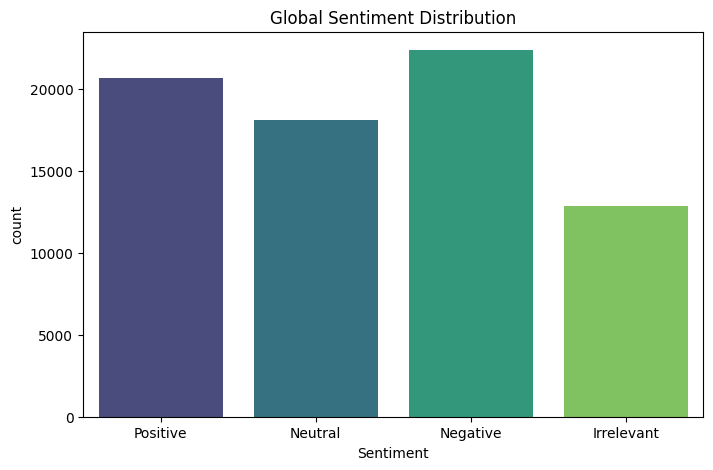

In [8]:
#Now We Can Visulize the Overall Sentiment 
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Global Sentiment Distribution')
plt.show()

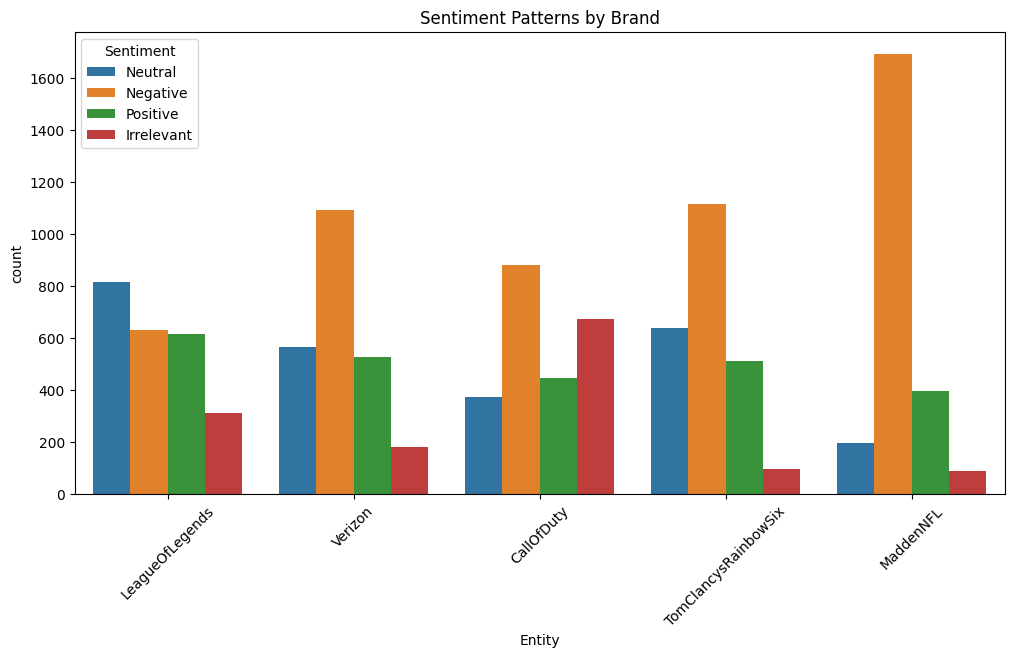

In [10]:
#Analysis of Brand-Specific {Top 5 Entities}
top_entities = df['Entity'].value_counts().head(5).index
subset = df[df['Entity'].isin(top_entities)]

plt.figure(figsize=(12, 6))
sns.countplot(x='Entity', hue='Sentiment', data=subset)
plt.title('Sentiment Patterns by Brand')
plt.xticks(rotation=45)
plt.show()

In [38]:
# Filter for Positive and Negative sentiments separately
pos_df = df[df['Sentiment'] == 'Positive']
neg_df = df[df['Sentiment'] == 'Negative']

# Combine the text for each
pos_text = " ".join(str(tweet) for tweet in pos_df['Tweet_Content'])
neg_text = " ".join(str(tweet) for tweet in neg_df['Tweet_Content'])

# We create a function to keep the code clean and professional
pos_cloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
neg_cloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(neg_text)



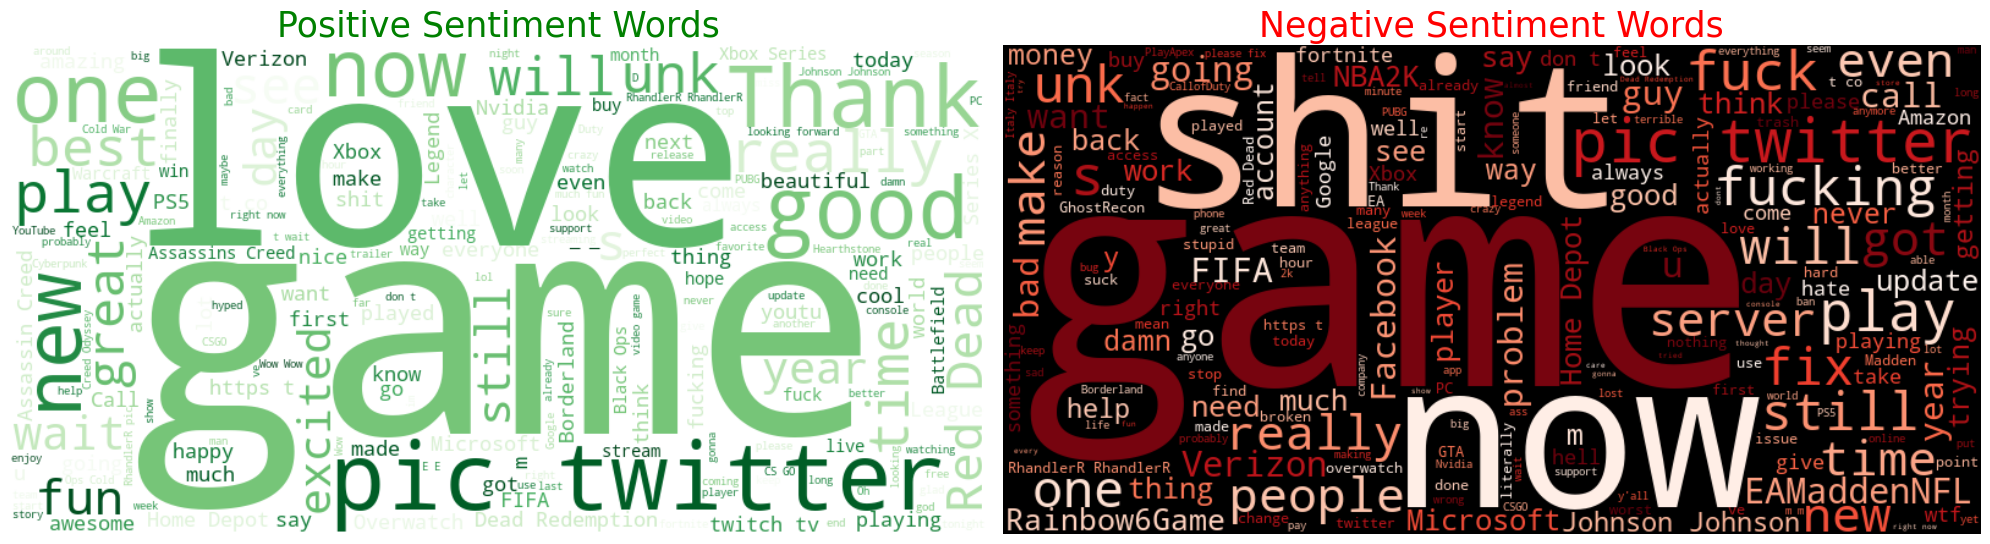

In [39]:

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Plot Positive
ax[0].imshow(pos_cloud, interpolation='bilinear')
ax[0].set_title('Positive Sentiment Words', fontsize=25, color='green')
ax[0].axis('off')

# Plot Negative
ax[1].imshow(neg_cloud, interpolation='bilinear')
ax[1].set_title('Negative Sentiment Words', fontsize=25, color='red')
ax[1].axis('off')

plt.tight_layout()
plt.show()